In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/AI/Data/FruitinAmazon (1).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [ ]:
import os
os.listdir("/content/dataset")

['FruitinAmazon']

In [ ]:
import os

os.listdir("/content")

['.config', 'drive', 'dataset', 'sample_data']

In [ ]:
os.listdir("/content/dataset")

['FruitinAmazon']

In [ ]:
import os
os.listdir("/content/dataset/FruitinAmazon")

['train', 'test']

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
train_dir = "/content/dataset/FruitinAmazon/train"

# **VERIFY DATASET**

In [ ]:
class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


# **CHECK CORRUPTED IMAGES**

In [ ]:
corrupted_images = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)
if corrupted_images:
    print("Corrupted:", corrupted_images)
else:
    print("No corrupted images found.")

No corrupted images found.


# **CHECK CLASS BALANCE**

In [ ]:
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)
print("Class Balance:")
for class_name, count in class_counts.items():
    print(f"{class_name:25} {count}")

Class Balance:
acai                      15
cupuacu                   15
graviola                  15
guarana                   15
pupunha                   15
tucuma                    15


# **VISUALIZE RANDOM IMAGES**

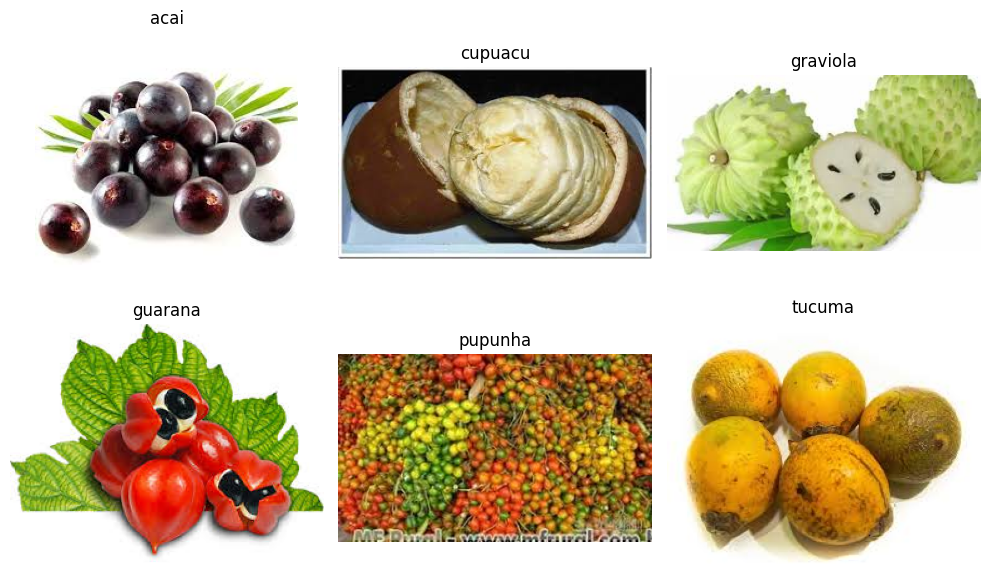

In [ ]:
import os, random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_dir = "/content/dataset/FruitinAmazon/train"

class_names = sorted(os.listdir(train_dir))

selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)

    img_path = os.path.join(class_path, random.choice(images))
    selected_images.append(img_path)
    selected_labels.append(class_name)

# Plot
plt.figure(figsize=(10,6))
for i in range(len(selected_images)):
    plt.subplot(2,3,i+1)
    img = mpimg.imread(selected_images[i])
    plt.imshow(img)
    plt.title(selected_labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

# **CREATE DATASET**

In [ ]:
from tensorflow import keras

image_size = (128, 128)
batch_size = 16   # smaller dataset → smaller batch

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


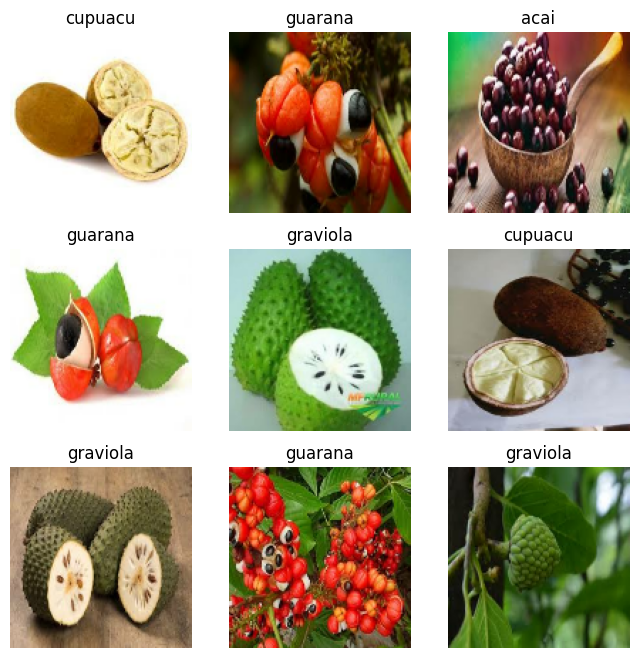

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [ ]:
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

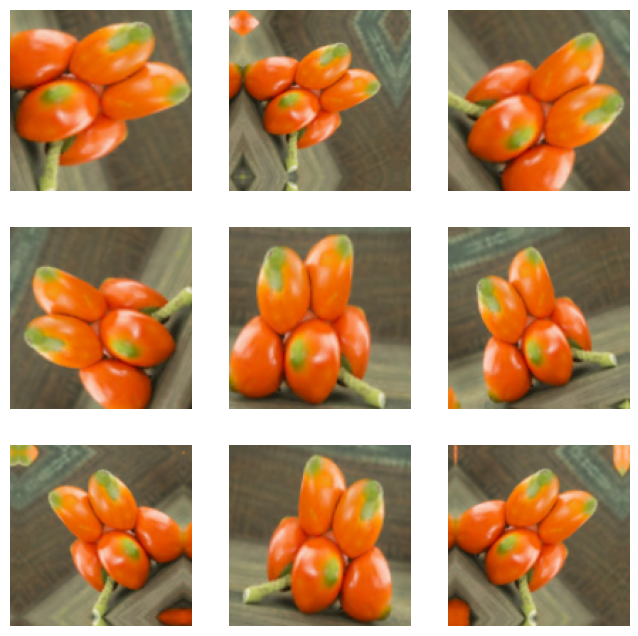

In [ ]:
plt.figure(figsize=(8,8))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented = data_augmentation(images)
        plt.subplot(3,3,i+1)
        plt.imshow(augmented[0].numpy().astype("uint8"))
        plt.axis("off")
plt.show()

In [ ]:
from tensorflow.keras import models, layers

model = models.Sequential([

    layers.Input(shape=(128,128,3)),

    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Dense
    layers.Flatten(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_16 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_11 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 6)              │         1,54

 Total params: 8,485,574 (32.37 MB)

 Trainable params: 8,484,614 (32.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.2778 - loss: 2.4268 - val_accuracy: 0.0556 - val_loss: 2.0859
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 840ms/step - accuracy: 0.5278 - loss: 1.4299 - val_accuracy: 0.0556 - val_loss: 1.8670
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 858ms/step - accuracy: 0.5278 - loss: 1.2434 - val_accuracy: 0.2222 - val_loss: 1.7947
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7361 - loss: 0.8244 - val_accuracy: 0.1667 - val_loss: 1.9137
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 835ms/step - accuracy: 0.6389 - loss: 1.0336 - val_accuracy: 0.1111 - val_loss: 1.9976
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7778 - loss: 0.6185 - val_accuracy: 0.1111 - val_loss: 2.0164
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 840ms/step - accuracy: 0.7222 - loss: 0.7324 - val_accuracy: 0.1111 - val_loss: 1.9992
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7361 - loss: 0.6638 - val_accuracy: 0.2222 - val_loss: 2.0660
Epo

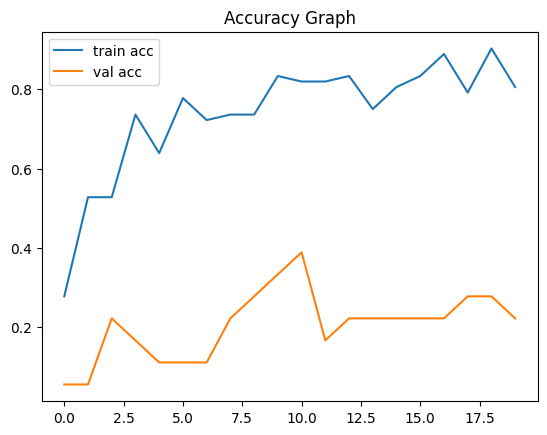

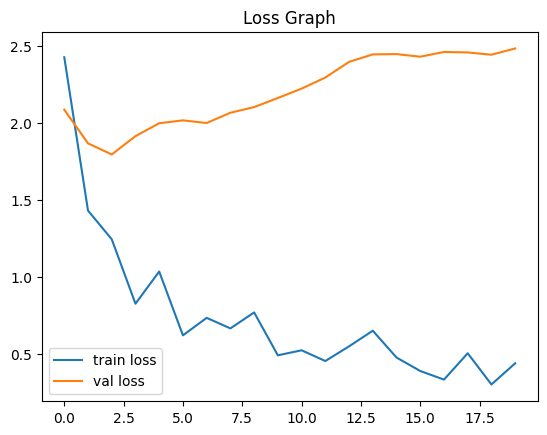

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.2222 - loss: 2.4838 
Validation Accuracy: 0.2222222238779068


Small Dataset Problem
Overfitting
High Model Complexity
Poor Generalization
Data Augmentation Limitations

# **TRANSFER LEARNING (VGG16)**

# **LOAD MODEL**

In [ ]:
from tensorflow.keras.applications import VGG16

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

# **FREEZE**

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

# **ADD LAYERS**

In [ ]:
from tensorflow.keras import layers, models

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(6, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

# **COMPILE**

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# **TRAIN**

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.2222 - loss: 13.6879 - val_accuracy: 0.1667 - val_loss: 9.5363
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.4306 - loss: 7.3259 - val_accuracy: 0.3333 - val_loss: 6.0861
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.6389 - loss: 2.9570 - val_accuracy: 0.3333 - val_loss: 5.9601
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - accuracy: 0.7639 - loss: 1.1709 - val_accuracy: 0.5000 - val_loss: 5.0620
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.8333 - loss: 0.8861 - val_accuracy: 0.5000 - val_loss: 5.3396
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.9306 - loss: 0.4764 - val_accuracy: 0.3889 - val_loss: 5.9183
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.9167 - loss: 0.5016 - val_accuracy: 0.4444 - val_loss: 6.3192
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.8472 - loss: 0.6522 - val_accuracy: 0.4444 - val_loss: 6.3841
Epoch 9

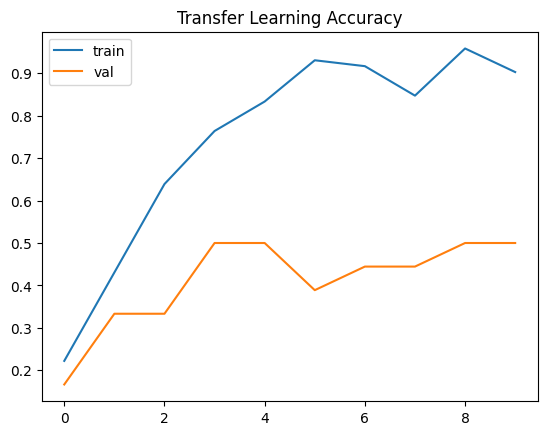

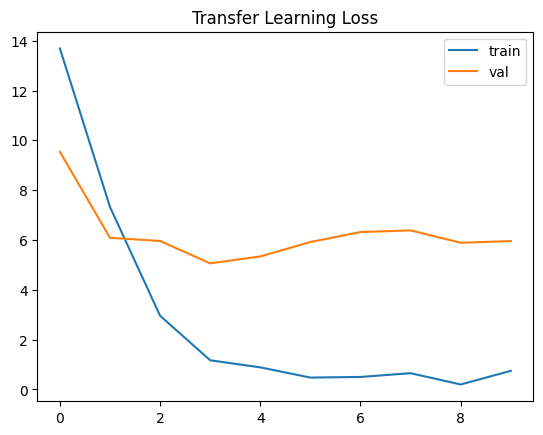

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Transfer Learning Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])
plt.title("Transfer Learning Loss")
plt.show()

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 493ms/step - accuracy: 0.5000 - loss: 5.9564
Validation Accuracy: 0.5
